## import necessary packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.optim as optim
import cv2
from tqdm.notebook import trange, tqdm
import random
from tqdm.auto import tqdm

import time

import sys, os
BASE = os.getcwd()  
if BASE not in sys.path:
    sys.path.append(BASE)
    
sys.path.append('../')
from funcs import *  

In [2]:
def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
setup_seed(42)
DEVICE = 'cuda'
n_pts = 928
pattern_shape = 768
obj = 'Box'

## setting # sampling points

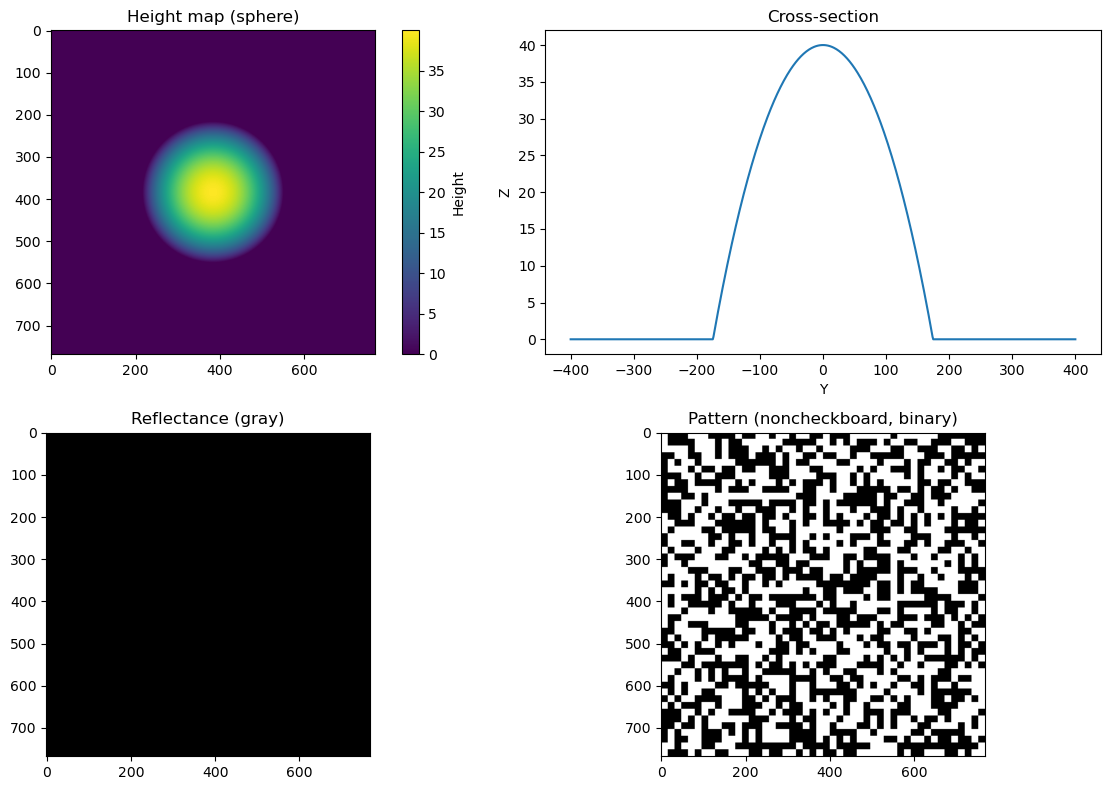

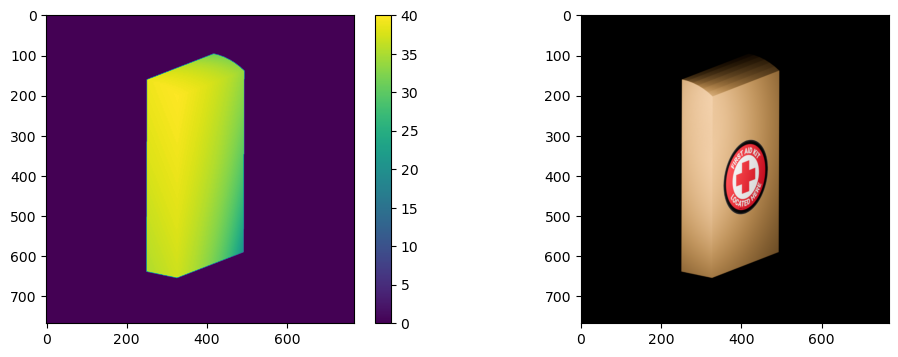

In [3]:
height_map, reflectance, pattern = generate_test_data(pattern_shape, square_size = 16, obj_source="sphere", 
                                                      pattern_source = "noncheckboard" , 
                                                      pattern_mode="binary",
                                                      reflectance_mode="gray")
file_path = '../Blender_test/'
relf_path = 'reflectance.png'
heig_path = 'heightmap.png'

# # --- height ---
height_np = cv2.imread(file_path + heig_path, cv2.IMREAD_GRAYSCALE)  # (H,W)
height_np = cv2.resize(height_np, (n_pts, n_pts))
height_np = height_np.astype(np.float32)
height_np = (height_np / (height_np.max() + 1e-12)) * 40.0

height_map = pad_to_size(torch.from_numpy(height_np), (int(pattern_shape*1.5), int(pattern_shape*1.5))).to(torch.float32)

# cv2.resize needs numpy
height_map_np = height_map.cpu().numpy()  # (H,W), float32
height_map_np = cv2.resize(height_map_np, (pattern_shape, pattern_shape), interpolation=cv2.INTER_LINEAR)

# back to torch
height_map = torch.from_numpy(height_map_np).to(torch.float32)
# height_map = height_map.to(device)

# --- reflectance ---
refl_np = cv2.imread(file_path + relf_path)          # (H, W, 3), BGR, uint8
refl_np = cv2.cvtColor(refl_np, cv2.COLOR_BGR2RGB)  # (H, W, 3), RGB
refl_np = cv2.resize(refl_np, (n_pts, n_pts))
refl_np = refl_np.astype(np.float32)

refl_np = refl_np / (refl_np.max() + 1e-12)          # (H, W, 3)

# ========== padding ==========
refl_pad = pad_to_size(
    torch.from_numpy(refl_np),                       # (H, W, 3)
    (int(pattern_shape * 1.5), int(pattern_shape * 1.5))
).numpy()                                            # (H2, W2, 3)

# ========== resize ==========
refl_pad = cv2.resize(
    refl_pad,
    (pattern_shape, pattern_shape),
    interpolation=cv2.INTER_LINEAR
)                                                    # (H, W, 3)

# ========== back to torch, channel-first ==========
reflectance = torch.from_numpy(refl_pad) \
    .permute(2, 0, 1) \
    .to(torch.float32)                               # (3, H, W)


# height_map = torch.rot90(height_map, k = 2,dims = (0,1))/height_map.max()*100
plt.figure(figsize = (12,4))
plt.subplot(121)
plt.imshow(height_map)
plt.colorbar()
plt.subplot(122)
plt.imshow(reflectance.permute(1,2,0))
plt.show()

In [6]:
from PIL import Image

def save_pattern_png(pattern: torch.Tensor, path="pattern.png", clamp=True):
    """
    pattern: torch.Tensor with shape (1, H, W) or (H, W)
    Saves as 8-bit grayscale PNG.
    """
    if pattern.dim() == 3:
        assert pattern.shape[0] == 1, f"Expected (1,H,W), got {tuple(pattern.shape)}"
        img = pattern[0]
    else:
        img = pattern

    img = img.detach().float().cpu()

    if clamp:
        # if you know it's already in [0,1], keep this
        img = img.clamp(0, 1)

    # normalize to [0,255] robustly (works even if not strictly [0,1])
    mn = float(img.min())
    mx = float(img.max())
    if mx > mn:
        img01 = (img - mn) / (mx - mn)
    else:
        img01 = torch.zeros_like(img)

    img_u8 = (img01 * 255.0).round().to(torch.uint8).numpy()
    Image.fromarray(img_u8, mode="L").save(path)
    print(f"Saved: {path} | range=({mn:.6g}, {mx:.6g}) | shape={img_u8.shape}")

# usage:
save_pattern_png(pattern, "pattern16_768.png")

Saved: pattern16_768.png | range=(0, 1) | shape=(768, 768)


In [27]:
# pattern_path = os.path.join("../Patterns/", "pattern_16.png")

# pattern = (torch.tensor(
#     cv2.imread(pattern_path)[:, :, [2, 1, 0]],
#     dtype=torch.float32
# ).permute(2, 0, 1) / 255.0)[0:1,:,:]

# plt.imshow(pattern.permute(1,2,0))
# plt.show()


## if use blender object refletance and height

In [5]:
calib_results = utils.json_loader(file_path=f'../Real_data/{obj}/{obj}_final_calibration_summary.json')
cam_COP = calib_results['camera_position_world']
cam_R = calib_results['R_world_to_camera']
cam_K = calib_results['camera_intrinsic']
proj_COP = calib_results['projector_position_world']
proj_R = calib_results['R_world_to_projector']
proj_K = calib_results['projector_intrinsic']

Projector focal (fx, fy): (2405.9962372020145, 2503.0073079538874)
Projector principal point offset (Δx, Δy): (13.869208331625885, 261.2089887642941)
Camera focal (fx, fy): (4550.583332930169, 4560.969653462267)
Camera principal point offset (Δx, Δy): (62.9898496654705, -70.75718807479461)
diff mean: 1.643791802052874e-05
diff max : 0.005307614803314209


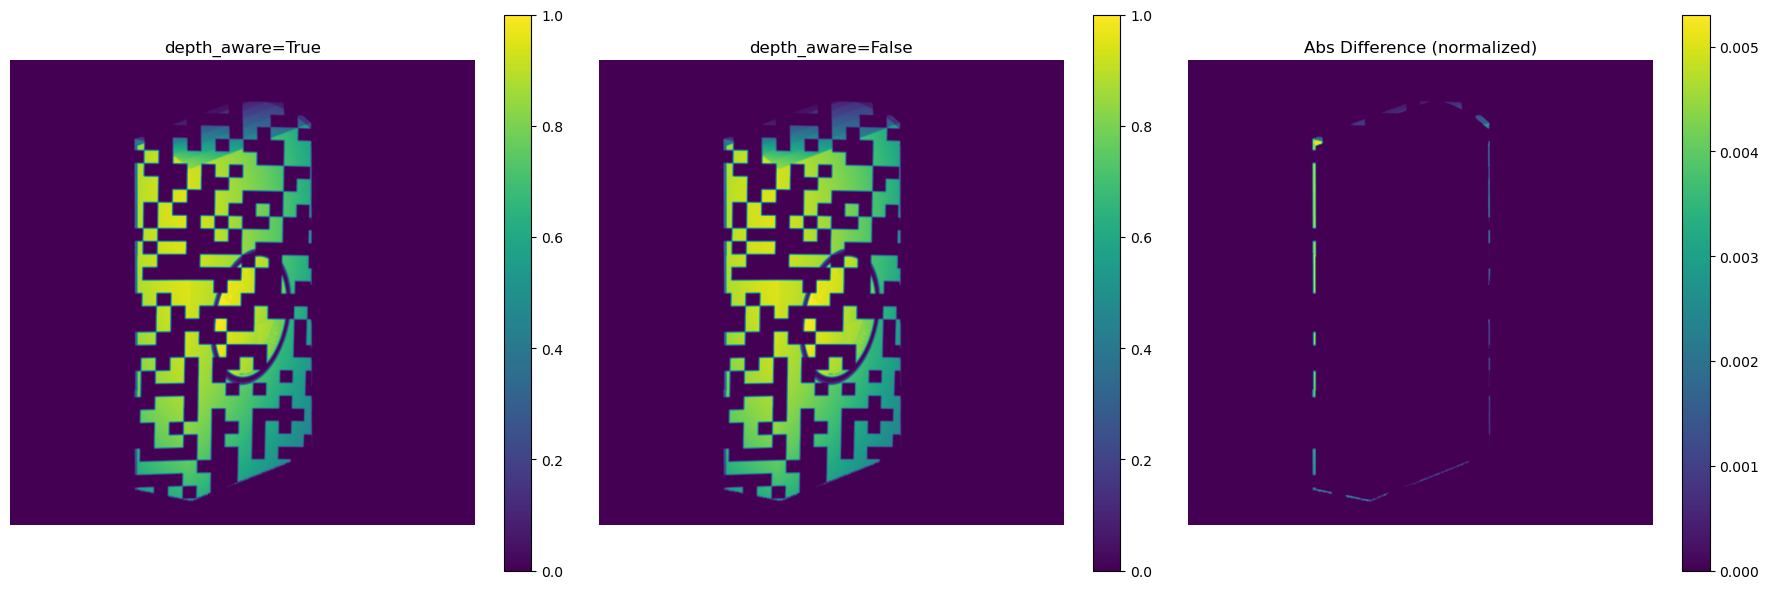

In [14]:
proj_t = -proj_R @ proj_COP
cam_t = -cam_R @ cam_COP


cam_res = (n_pts, n_pts)   
proj_res = (pattern_shape, pattern_shape)  

intrinsics_para = parse_intrinsics(cam_K, proj_K, cam_res, proj_res)

print("Projector focal (fx, fy):", intrinsics_para["projector"]["focal"])
print("Projector principal point offset (Δx, Δy):", intrinsics_para["projector"]["offset"])
print("Camera focal (fx, fy):", intrinsics_para["camera"]["focal"])
print("Camera principal point offset (Δx, Δy):", intrinsics_para["camera"]["offset"])


proj_sensor_size = min(proj_res)
proj_fx, proj_fy = intrinsics_para["projector"]["focal"]   # (fx, fy)
proj_cx_px, proj_cy_px = intrinsics_para["projector"]["offset"]

cam_sensor_size = min(cam_res)
cam_fx,  cam_fy  = intrinsics_para["camera"]["focal"]      # (fx, fy)
cam_cx_px, cam_cy_px = intrinsics_para["camera"]["offset"]
extent_mm = [-200, 200, -200, 200]   
 
# -----------------------------
# Build a plane (whiteboard)
# -----------------------------
A = 0.014215
B = 0.008262
C = 0.999865
D = 0.949929

xmin, xmax, ymin, ymax = extent_mm
num = proj_res

x = torch.linspace(xmin, xmax, num[0], device=DEVICE)
y = torch.linspace(ymin, ymax, num[1], device=DEVICE)
X, Y = torch.meshgrid(x, y, indexing="xy")

height_map_whiteboard = -(A * X + B * Y + D) / C

# -----------------------------
# Instantiate model
# -----------------------------
cam_resolution = n_pts
imager2 = Proj_Cam_model_ablation(
    proj_f=(proj_fx, proj_fy),
    cam_f=(cam_fx, cam_fy),

    proj_sensor_w_px=proj_sensor_size,
    proj_sensor_h_px=proj_sensor_size,
    cam_sensor_px=cam_sensor_size,
    # proj_COP=[200.0, 0.0, 1500.0], cam_COP=[-400.0, 200.0, 1500.0],
    proj_R=proj_R, proj_t=proj_t,
    cam_R=cam_R, cam_t=cam_t,

    proj_cx_px=proj_cx_px ,
    proj_cy_px=proj_cy_px ,
    cam_cx_px=cam_cx_px,
    cam_cy_px=cam_cy_px,

    device=DEVICE
)

# -----------------------------
# Occluder: closer disk (two depths)
# -----------------------------
height_map_bg = height_map_whiteboard.clone()
height_map_occ = height_map_bg.clone()

r_mm = 90.0
disk_mask = (X**2 + Y**2) < (r_mm**2)

depth_jump = 800.0
height_map_occ[disk_mask] = height_map_bg[disk_mask] - depth_jump

# -----------------------------
depth_flags = [1, 0]
measured_imgs = []
height_map = height_map*1
for depth_on in depth_flags:
    measured_img = torch.zeros((pattern.shape[0], n_pts, n_pts), device=DEVICE)

    for c in range(pattern.shape[0]):
        measured_img2 = imager2.render(
            height_map*1,
            # height_map_occ,
            # height_map*5,
            # torch.tensor(height_map_Z*10, device = DEVICE,dtype=torch.float32),
            reflectance[c, :, :],
            pattern[c, :, :],
            extent_mm=extent_mm,
            cam_res=(cam_resolution, cam_resolution),
            use_soft_z_buffer=1,
            sigma_softz=1,
            radius_multi_softz=4.0,
            steepness_softz=200,
            depth_aware=depth_on
        )
        measured_img[c, :, :] = measured_img2.squeeze()

    measured_imgs.append(measured_img/measured_img.max())

# -----------------------------
# Diff + visualization (3 subplots)
# -----------------------------
diff = (measured_imgs[1] - measured_imgs[0]).abs()

print("diff mean:", diff.mean().item())
print("diff max :", diff.max().item())

# scale = 1.0
# if diff.max() > 0:
#     scale = 1.0 / diff.max().item()

img_true  = measured_imgs[0].permute(1, 2, 0).detach().cpu()
img_false = measured_imgs[1].permute(1, 2, 0).detach().cpu()
diff_vis  = diff.permute(1, 2, 0).detach().cpu() 

# Avoid matplotlib warning by clamping displayed RGB to [0,1]
img_true  = img_true.clamp(0, 1)
img_false = img_false.clamp(0, 1)


plt.figure(figsize=(18, 6))

# --- subplot 1 ---
plt.subplot(1, 3, 1)
plt.imshow(img_true, origin="lower",vmin = 0)
plt.title("depth_aware=True")
plt.colorbar()
plt.axis("off")

# --- subplot 2 ---
plt.subplot(1, 3, 2)
plt.imshow(img_false, origin="lower",vmin = 0)
plt.colorbar()
plt.title("depth_aware=False")
plt.axis("off")

# --- subplot 3 ---
plt.subplot(1, 3, 3)
plt.imshow(diff_vis, origin="lower")
plt.colorbar()
plt.title("Abs Difference (normalized)")
plt.axis("off")

# 绑定当前 subplot 的 colorbar


plt.tight_layout()
plt.show()